In [9]:
!unzip -q /content/*.zip -d /content/dms_raw
print("Extraction complete!")

Extraction complete!


In [10]:
import os
import glob
import yaml
import shutil

print("--- Starting Processing Pipeline ---")

# 1. SETUP FINAL FOLDERS
output_base = '/content/dms_processed_yolo'
splits = ['train', 'valid', 'test']

# Cleaning up any old runs
if os.path.exists(output_base):
    shutil.rmtree(output_base)

for split in splits:
    os.makedirs(os.path.join(output_base, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_base, split, 'labels'), exist_ok=True)

# 2. FILTER & REMAP CLASSES
# Adjust '3' and '4' if original dataset uses different IDs for Phone and Seatbelt
CLASS_MAP = {'3': '0', '4': '1'}
stats = {'Phone': 0, 'Seatbelt': 0, 'Total_Images': 0}

for split in splits:
    raw_img_dir = os.path.join('/content/dms_raw', split, 'images')
    raw_lbl_dir = os.path.join('/content/dms_raw', split, 'labels')

    # Handle naming variations (sometimes 'valid' is called 'val')
    if not os.path.exists(raw_img_dir) and split == 'valid':
        raw_img_dir = os.path.join('/content/dms_raw', 'val', 'images')
        raw_lbl_dir = os.path.join('/content/dms_raw', 'val', 'labels')

    if not os.path.exists(raw_img_dir):
        continue

    # Find all images
    image_paths = glob.glob(os.path.join(raw_img_dir, '*.jpg')) + \
                  glob.glob(os.path.join(raw_img_dir, '*.png'))

    for img_path in image_paths:
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        txt_path = os.path.join(raw_lbl_dir, f"{base_name}.txt")

        if not os.path.exists(txt_path):
            continue

        with open(txt_path, 'r') as f:
            lines = f.readlines()

        valid_lines = []
        for line in lines:
            parts = line.strip().split()
            if not parts: continue

            class_id = parts[0]
            if class_id in CLASS_MAP:
                # Basic quality check: ensure coordinates are valid YOLO format (0 to 1)
                coords = [float(x) for x in parts[1:]]
                if any(c < 0.0 or c > 1.0 for c in coords):
                    continue

                parts[0] = CLASS_MAP[class_id]
                valid_lines.append(" ".join(parts) + "\n")

                if parts[0] == '0': stats['Phone'] += 1
                if parts[0] == '1': stats['Seatbelt'] += 1

        # If we kept at least one valid box, copy the image and new label over
        if valid_lines:
            stats['Total_Images'] += 1
            shutil.copy(img_path, os.path.join(output_base, split, 'images', os.path.basename(img_path)))

            with open(os.path.join(output_base, split, 'labels', f"{base_name}.txt"), 'w') as f:
                f.writelines(valid_lines)

print(f"\n--- Metrics ---")
print(f"Total Filtered Images Saved: {stats['Total_Images']}")
print(f"Total Phone Boxes: {stats['Phone']}")
print(f"Total Seatbelt Boxes: {stats['Seatbelt']}")

# 3. CREATE DATA.YAML
yaml_data = {
    'train': '../train/images',
    'val': '../valid/images',
    'test': '../test/images',
    'nc': 2,
    'names': ['Phone', 'Seatbelt']
}

with open(os.path.join(output_base, 'data.yaml'), 'w') as f:
    yaml.dump(yaml_data, f, sort_keys=False)

# 4. ZIPPING FINAL FOLDER FOR DOWNLOAD
archive_path = '/content/Sohini_Processed_Dataset'
shutil.make_archive(archive_path, 'zip', output_base)

print(f"\n--- SUCCESS! ---")
print(f"Clean dataset is ready. Please download 'Sohini_Processed_Dataset.zip'.")

--- Starting Processing Pipeline ---

--- Metrics ---
Total Filtered Images Saved: 6140
Total Phone Boxes: 2552
Total Seatbelt Boxes: 4149

--- SUCCESS! ---
Clean dataset is ready. Please download 'Sohini_Processed_Dataset.zip'.


--- Generating Fundamental Object Detection EDA ---


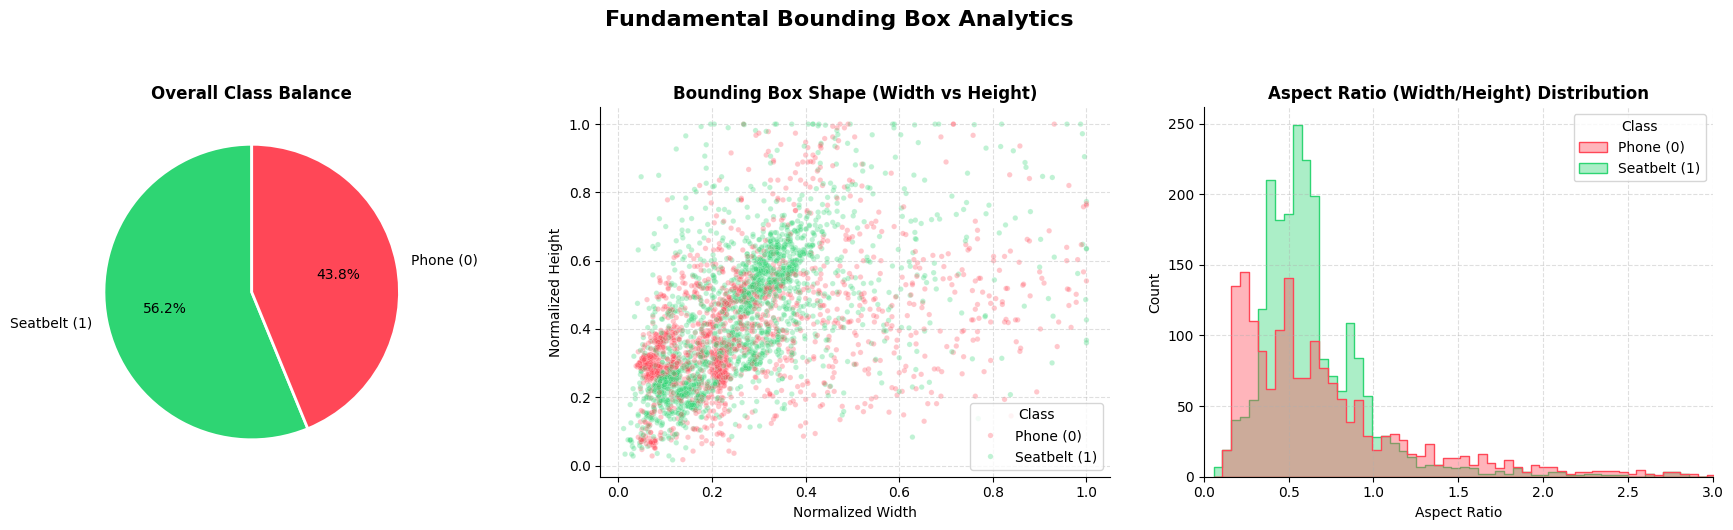

Saved: /content/basic_yolo_eda.png


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths based on your processed dataset
train_labels_dir = '/content/dms_processed_yolo/train/labels'

print("--- Generating Fundamental Object Detection EDA ---")

# 1. Gather the basic dimensional data
data = []
valid_files = [f for f in os.listdir(train_labels_dir) if f.endswith('.txt')]

for txt_file in valid_files:
    with open(os.path.join(train_labels_dir, txt_file), 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, x, y, w, h = map(float, parts)

                class_name = 'Phone (0)' if class_id == 0.0 else 'Seatbelt (1)'
                aspect_ratio = w / h if h > 0 else 0

                data.append({
                    'Class': class_name,
                    'Width': w,
                    'Height': h,
                    'Aspect_Ratio': aspect_ratio
                })

df = pd.DataFrame(data)

if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Fundamental Bounding Box Analytics', fontsize=16, fontweight='bold', y=1.05)

    # Plot 1: Overall Class Balance (Pie Chart)
    class_counts = df['Class'].value_counts()
    axes[0].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
                colors=['#2ed573', '#ff4757'], startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[0].set_title('Overall Class Balance', fontweight='bold')

    # Plot 2: Width vs Height Scatter (Shape Analysis)
    sns.scatterplot(data=df, x='Width', y='Height', hue='Class',
                    palette={'Phone (0)': '#ff4757', 'Seatbelt (1)': '#2ed573'},
                    alpha=0.3, s=15, ax=axes[1])
    axes[1].set_title('Bounding Box Shape (Width vs Height)', fontweight='bold')
    axes[1].set_xlabel('Normalized Width')
    axes[1].set_ylabel('Normalized Height')
    axes[1].grid(linestyle='--', alpha=0.4)

    # Plot 3: Aspect Ratio Distribution
    sns.histplot(data=df, x='Aspect_Ratio', hue='Class', element="step",
                 palette={'Phone (0)': '#ff4757', 'Seatbelt (1)': '#2ed573'},
                 ax=axes[2], common_norm=False, alpha=0.4)
    axes[2].set_title('Aspect Ratio (Width/Height) Distribution', fontweight='bold')
    axes[2].set_xlabel('Aspect Ratio')
    axes[2].set_ylabel('Count')
    axes[2].set_xlim(0, 3)
    axes[2].grid(linestyle='--', alpha=0.4)

    sns.despine(ax=axes[1])
    sns.despine(ax=axes[2])
    plt.tight_layout()

    basic_chart_path = '/content/basic_yolo_eda.png'
    plt.savefig(basic_chart_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {basic_chart_path}")
else:
    print("No bounding box data found to plot.")

--- Generating Advanced Spatial EDA ---


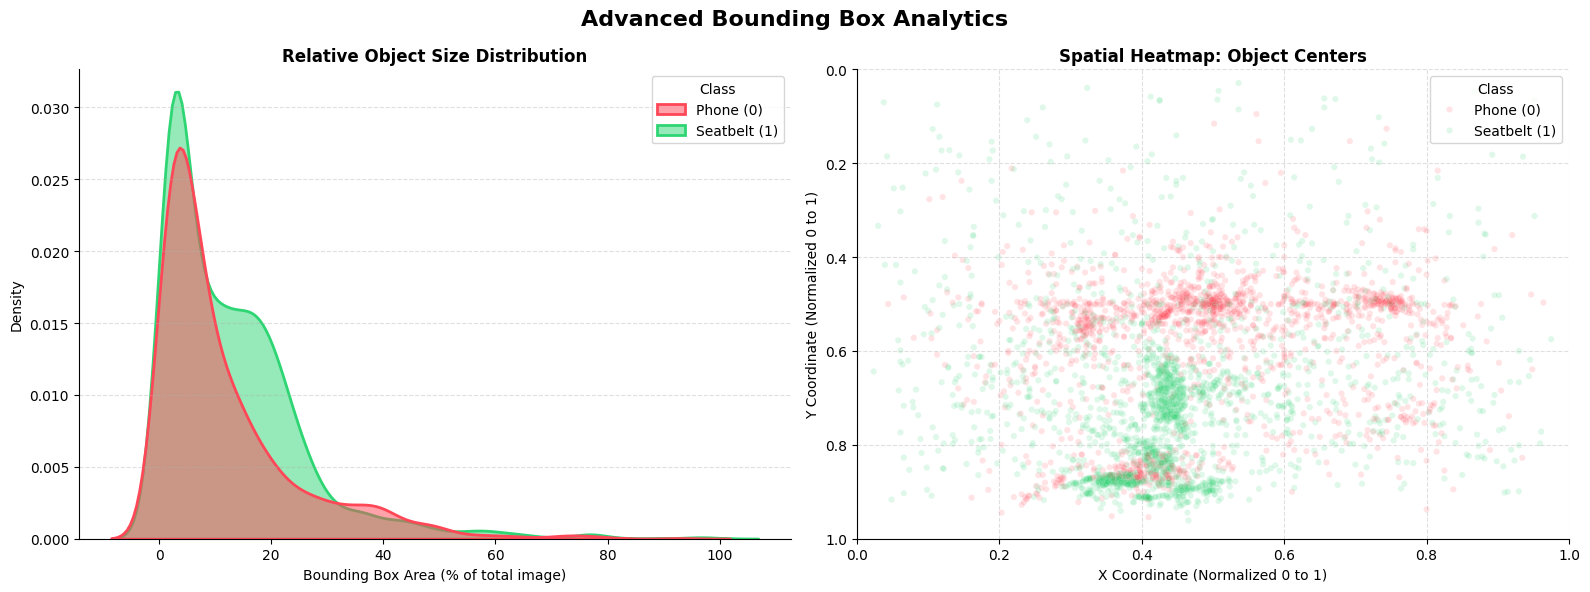

Saved: /content/advanced_spatial_eda.png


In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_labels_dir = '/content/dms_processed_yolo/train/labels'

print("--- Generating Advanced Spatial EDA ---")

# 1. Parse all labels into a DataFrame
data = []
valid_files = [f for f in os.listdir(train_labels_dir) if f.endswith('.txt')]

for txt_file in valid_files:
    with open(os.path.join(train_labels_dir, txt_file), 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, x, y, w, h = map(float, parts)

                # YOLO format gives normalized width and height. Area = w * h
                area = (w * h) * 100
                class_name = 'Phone (0)' if class_id == 0.0 else 'Seatbelt (1)'

                data.append({
                    'Class': class_name,
                    'X_Center': x,
                    'Y_Center': y,
                    'Area_Percent': area
                })

df = pd.DataFrame(data)

if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Advanced Bounding Box Analytics', fontsize=16, fontweight='bold')

    # Plot 1: Object Size (Area) Distribution
    sns.kdeplot(data=df, x='Area_Percent', hue='Class', fill=True,
                palette={'Phone (0)': '#ff4757', 'Seatbelt (1)': '#2ed573'},
                ax=axes[0], alpha=0.5, linewidth=2)

    axes[0].set_title('Relative Object Size Distribution', fontweight='bold')
    axes[0].set_xlabel('Bounding Box Area (% of total image)')
    axes[0].set_ylabel('Density')
    axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    # Plot 2: Spatial Distribution Heatmap
    sns.scatterplot(data=df, x='X_Center', y='Y_Center', hue='Class',
                    palette={'Phone (0)': '#ff4757', 'Seatbelt (1)': '#2ed573'},
                    alpha=0.15, s=20, ax=axes[1])

    axes[1].set_title('Spatial Heatmap: Object Centers', fontweight='bold')
    axes[1].set_xlabel('X Coordinate (Normalized 0 to 1)')
    axes[1].set_ylabel('Y Coordinate (Normalized 0 to 1)')

    # Invert Y-axis so the plot matches how images are rendered (0,0 at top left)
    axes[1].invert_yaxis()
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(1, 0)
    axes[1].grid(linestyle='--', alpha=0.4)

    sns.despine()
    plt.tight_layout()

    adv_chart_path = '/content/advanced_spatial_eda.png'
    plt.savefig(adv_chart_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {adv_chart_path}")
else:
    print("No bounding box data found to plot.")

In [13]:
import os
import glob

dataset_dir = '/content/dms_processed_yolo'
splits = ['train', 'valid', 'test']

print("==================================================")
print(" 1. CLASS MAPPING & DOCUMENTATION")
print("==================================================")
print("Target classes tracked explicitly via YOLO bounding boxes:")
print(" - Class 0: 'Phone' (Covers: phone, phone usage, mobile near driver)")
print(" - Class 1: 'Seatbelt' (Covers: seat belt, person with seat belt)")
print("\nNegative states handled implicitly (Absence of bounding box):")
print(" - 'no seat belt' / 'person without seat belt'")
print(" - 'no phone usage'")
print("==================================================\n")

print("==================================================")
print(" 2. DATASET SIZE & METRICS CHECK")
print("==================================================")

total_images = 0
total_labels = 0
class_counts = {'0 (Phone)': 0, '1 (Seatbelt)': 0}

for split in splits:
    img_dir = os.path.join(dataset_dir, split, 'images')
    lbl_dir = os.path.join(dataset_dir, split, 'labels')

    # Handle 'val' naming variation
    if not os.path.exists(img_dir) and split == 'valid':
        img_dir = os.path.join(dataset_dir, 'val', 'images')
        lbl_dir = os.path.join(dataset_dir, 'val', 'labels')

    if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
        print(f"Skipping {split} - Directory not found.")
        continue

    # Count Images
    images = glob.glob(os.path.join(img_dir, '*.jpg')) + glob.glob(os.path.join(img_dir, '*.png'))
    split_img_count = len(images)
    total_images += split_img_count

    # Count Labels
    labels = glob.glob(os.path.join(lbl_dir, '*.txt'))
    split_lbl_count = len(labels)
    total_labels += split_lbl_count

    # Count Bounding Boxes
    for txt_file in labels:
        with open(txt_file, 'r') as f:
            for line in f:
                class_id = line.strip().split()[0]
                if class_id == '0':
                    class_counts['0 (Phone)'] += 1
                elif class_id == '1':
                    class_counts['1 (Seatbelt)'] += 1

    print(f"[{split.upper()} SPLIT]")
    print(f"  - Images: {split_img_count}")
    print(f"  - Label Files: {split_lbl_count}")

print("\n[TOTAL DATASET METRICS]")
print(f"  - Total Images: {total_images}")
print(f"  - Total Label Files: {total_labels}")
print(f"  - Total 'Phone' Bounding Boxes: {class_counts['0 (Phone)']}")
print(f"  - Total 'Seatbelt' Bounding Boxes: {class_counts['1 (Seatbelt)']}")
print("==================================================")

 1. CLASS MAPPING & DOCUMENTATION
Target classes tracked explicitly via YOLO bounding boxes:
 - Class 0: 'Phone' (Covers: phone, phone usage, mobile near driver)
 - Class 1: 'Seatbelt' (Covers: seat belt, person with seat belt)

Negative states handled implicitly (Absence of bounding box):
 - 'no seat belt' / 'person without seat belt'
 - 'no phone usage'

 2. DATASET SIZE & METRICS CHECK
[TRAIN SPLIT]
  - Images: 3534
  - Label Files: 3534
[VALID SPLIT]
  - Images: 1959
  - Label Files: 1959
[TEST SPLIT]
  - Images: 647
  - Label Files: 647

[TOTAL DATASET METRICS]
  - Total Images: 6140
  - Total Label Files: 6140
  - Total 'Phone' Bounding Boxes: 2552
  - Total 'Seatbelt' Bounding Boxes: 4149


In [14]:
!pip install opencv-python

--- Visual Quality Check: Inspecting Processed Annotations ---


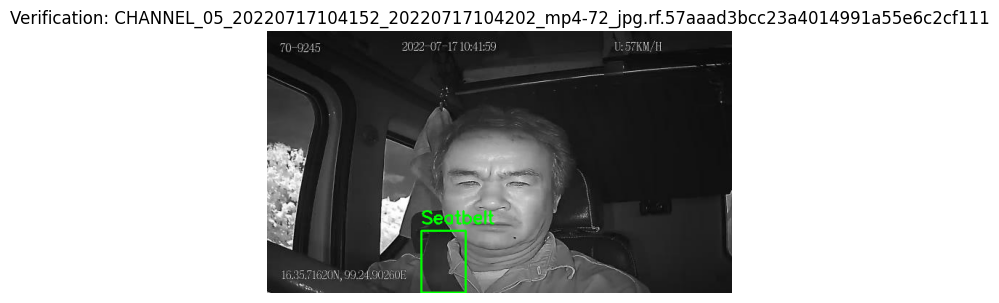

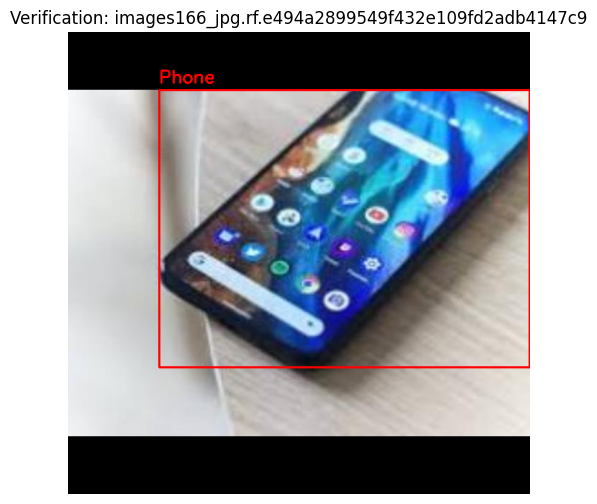

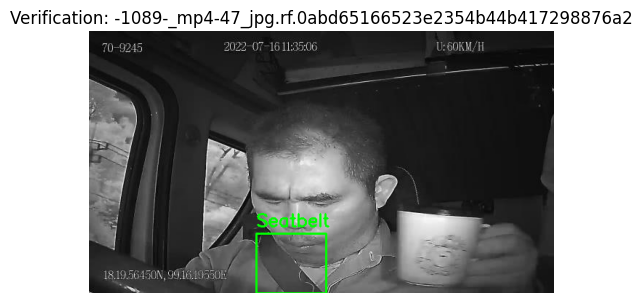

In [15]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
import random

# Path to your processed training images and labels
images_dir = '/content/dms_processed_yolo/train/images'
labels_dir = '/content/dms_processed_yolo/train/labels'
class_names = ['Phone', 'Seatbelt']

# Get a random selection of images to check
image_files = glob.glob(os.path.join(images_dir, '*.jpg')) + glob.glob(os.path.join(images_dir, '*.png'))
sample_images = random.sample(image_files, min(3, len(image_files)))

print("--- Visual Quality Check: Inspecting Processed Annotations ---")

for img_path in sample_images:
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(labels_dir, f"{base_name}.txt")

    # Read image
    img = cv2.imread(img_path)
    h, w, _ = img.shape

    # Read YOLO label file if it exists
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if not parts: continue

            class_id = int(parts[0])
            x_center, y_center, box_w, box_h = map(float, parts[1:])

            # Convert YOLO normalized coordinates to pixel coordinates
            xmin = int((x_center - box_w / 2) * w)
            ymin = int((y_center - box_h / 2) * h)
            xmax = int((x_center + box_w / 2) * w)
            ymax = int((y_center + box_h / 2) * h)

            # Define colors: Red for Phone (0), Green for Seatbelt (1)
            color = (0, 0, 255) if class_id == 0 else (0, 255, 0)
            label_text = class_names[class_id]

            # Draw bounding box and label
            cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 2)
            cv2.putText(img, label_text, (xmin, max(35, ymin - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Verification: {base_name}")
    plt.show()

In [16]:
# Milestone 3 (Model Architecture & End-to-End Pipeline Verification)


# Install Ultralytics YOLO framework
!pip install ultralytics -q

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Initialize the model architecture
model = YOLO('yolov8n.pt')
print("--- Milestone 3: YOLOv8n Architecture Initialized Successfully ---")

--- Milestone 3: YOLOv8n Architecture Initialized Successfully ---


In [17]:
import os

dataset_dir = '/content/dms_processed_yolo'

if os.path.exists(dataset_dir):
    print("Files/Folders inside dms_processed_yolo:")
    for root, dirs, files in os.walk(dataset_dir):
        level = root.replace(dataset_dir, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        # Show first 3 files per directory
        for f in files[:3]:
            print(f"{subindent}{f}")
        if len(files) > 3:
            print(f"{subindent}... ({len(files) - 3} more files)")
else:
    print(f"Directory '{dataset_dir}' does not exist! Check where your dataset was uploaded or extracted.")

Files/Folders inside dms_processed_yolo:
dms_processed_yolo/
    data.yaml
    train/
        images/
            gray-YRYVP9J642F0_jpg.rf.632f948839a241705370d9e9913b9977.jpg
            84fd24213b0c25d0_jpg.rf.a24b66640f1b1a6bd0a71723e5484869.jpg
            CHANNEL_05_20220717104152_20220717104202_mp4-46_jpg.rf.2cdfafad4486c6b55013d341bab60a93.jpg
            ... (3531 more files)
        labels/
            139_jpg.rf.e3459605aa0fcfc6297a91b53c0f0b53.txt
            images46_jpg.rf.3f9656eff658604e5d7c88dd0d29459d.txt
            CHANNEL_05_20220717185741_20220717185751_mp4-91_jpg.rf.3e2ff1f4bc571413a5032ca881214f10.txt
            ... (3531 more files)
    test/
        images/
            gray-W0RSN4S8DWPX_jpg.rf.304c289cb03f54533b1605a9a129ebcf.jpg
            image9_jpeg_jpg.rf.d297563c28c63e8b60e7929b353ca98a.jpg
            CHANNEL_05_20220601042057_20220601042103_mp4-22_jpg.rf.247853c2fc107f7973ac82f303b0ce97.jpg
            ... (644 more files)
        labels/
            i

In [19]:
from ultralytics import YOLO
import os

print("--- Starting Proper YOLOv8 Training for Driver Monitoring System ---")

# 1. Load fresh pretrained model
model = YOLO('yolov8n.pt')

# 2. Train the model on your custom processed dataset
# 15 epochs is enough to see a massive jump in accuracy for a structured dataset like this on a GPU
results = model.train(
    data='/content/dms_processed_yolo/data.yaml',
    epochs=25,
    imgsz=640,
    batch=16,
    device=0,          # Uses GPU (T4)
    save=True,
    plots=True,
    verbose=True,
    cache=True,
    amp=True
)

print("\n--- Training Complete! Best weights saved. ---")

--- Starting Proper YOLOv8 Training for Driver Monitoring System ---
Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.7.1+cu118 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dms_processed_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momen

In [20]:
import pandas as pd

results_df = pd.read_csv('/content/runs/detect/train/results.csv')
display(results_df)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,74.6449,1.30579,2.25730,1.40742,0.68785,0.66122,0.71079,0.38633,1.47526,2.02977,1.51788,0.000553,0.000553,0.000553
1,2,139.3770,1.37001,1.74245,1.44290,0.47183,0.48643,0.35031,0.16308,1.71825,3.93085,1.82344,0.001065,0.001065,0.001065
2,3,205.6110,1.38593,1.60024,1.45944,0.59173,0.56421,0.61603,0.34646,1.49014,1.78879,1.52151,0.001533,0.001533,0.001533
3,4,270.4600,1.35685,1.43570,1.43526,0.73552,0.63429,0.70907,0.42468,1.39413,1.34111,1.49695,0.001469,0.001469,0.001469
4,5,333.1710,1.31741,1.37043,1.40805,0.81202,0.72623,0.79371,0.47768,1.36145,1.14962,1.45219,0.001403,0.001403,0.001403
5,6,395.0590,1.26555,1.27633,1.36955,0.82401,0.75313,0.82334,0.48933,1.34172,1.10143,1.43132,0.001337,0.001337,0.001337
6,7,457.2190,1.20329,1.19169,1.33220,0.84029,0.73688,0.84233,0.50376,1.28426,1.05936,1.37535,0.001271,0.001271,0.001271
7,8,520.2640,1.19447,1.15048,1.32321,0.86337,0.70389,0.83565,0.53687,1.23354,0.96154,1.32741,0.001205,0.001205,0.001205
8,9,585.3550,1.16126,1.09803,1.30207,0.83900,0.74022,0.85213,0.51984,1.29276,1.00318,1.36307,0.001139,0.001139,0.001139
9,10,648.3570,1.13791,1.01985,1.28306,0.83464,0.83789,0.89901,0.56754,1.20047,0.87097,1.30484,0.001073,0.001073,0.001073


--- Locating Trained Weights ---
Loading weights from: /content/runs/detect/train-2/weights/best.pt

image 1/1 /content/dms_processed_yolo/test/images/gray-W0RSN4S8DWPX_jpg.rf.304c289cb03f54533b1605a9a129ebcf.jpg: 640x480 1 Seatbelt, 10.3ms
Speed: 1.5ms preprocess, 10.3ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 480)


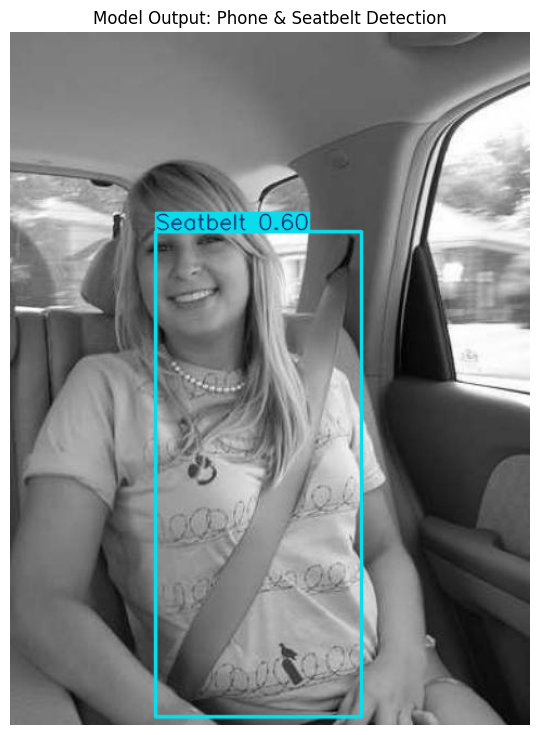

Successfully evaluated trained model on: /content/dms_processed_yolo/test/images/gray-W0RSN4S8DWPX_jpg.rf.304c289cb03f54533b1605a9a129ebcf.jpg


In [21]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("--- Locating Trained Weights ---")

# Automatically find the most recent 'best.pt' file
weights_files = glob.glob('/content/runs/detect/**/weights/best.pt', recursive=True)

if not weights_files:
    print("Error: Could not find any trained weights. Did the training cell finish successfully?")
else:
    # Sort files by modification time to get the newest one
    weights_files.sort(key=os.path.getmtime, reverse=True)
    best_model_path = weights_files[0]
    print(f"Loading weights from: {best_model_path}")

    # Load your newly trained high-performance weights
    trained_model = YOLO(best_model_path)

    # Pick an image from the test set
    test_images = glob.glob('/content/dms_processed_yolo/test/images/*.jpg') + \
                  glob.glob('/content/dms_processed_yolo/test/images/*.png')

    if test_images:
        sample_image = test_images[0]

        # Run prediction using the trained model
        pred_results = trained_model(sample_image, conf=0.4)

        # Plot and render results
        res_plotted = pred_results[0].plot()
        res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(9, 9))
        plt.imshow(res_rgb)
        plt.axis('off')
        plt.title('Model Output: Phone & Seatbelt Detection')
        plt.show()
        print(f"Successfully evaluated trained model on: {sample_image}")
    else:
        print("No test images found in '/content/dms_processed_yolo/test/images/'.")


image 1/1 /content/dms_processed_yolo/test/images/gray-W0RSN4S8DWPX_jpg.rf.304c289cb03f54533b1605a9a129ebcf.jpg: 640x480 1 Seatbelt, 12.9ms
Speed: 2.2ms preprocess, 12.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 480)


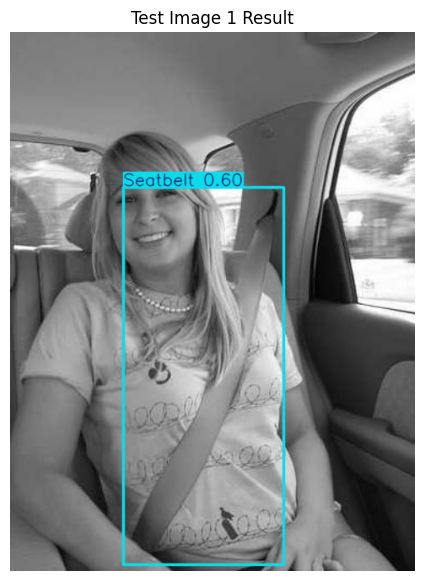


image 1/1 /content/dms_processed_yolo/test/images/image9_jpeg_jpg.rf.d297563c28c63e8b60e7929b353ca98a.jpg: 640x640 1 Phone, 43.7ms
Speed: 3.9ms preprocess, 43.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


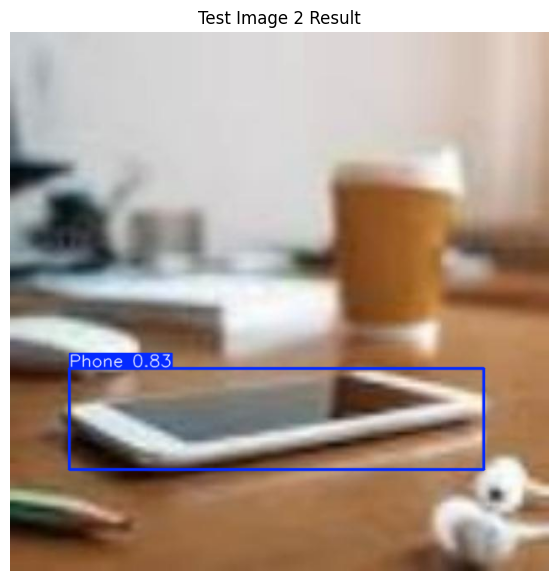


image 1/1 /content/dms_processed_yolo/test/images/CHANNEL_05_20220601042057_20220601042103_mp4-22_jpg.rf.247853c2fc107f7973ac82f303b0ce97.jpg: 384x640 2 Seatbelts, 44.3ms
Speed: 3.0ms preprocess, 44.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


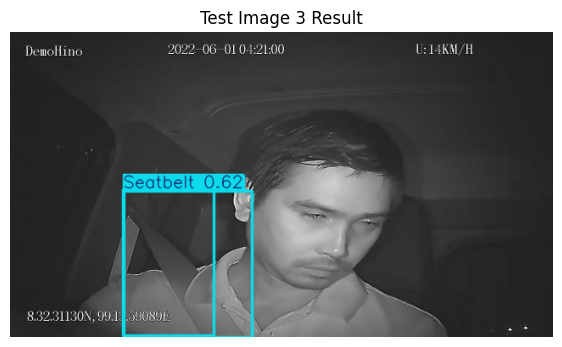

In [22]:
# Loop through the first 3 test images to see varied predictions
for i in range(min(3, len(test_images))):
    sample_image = test_images[i]
    pred_results = trained_model(sample_image, conf=0.3)

    res_plotted = pred_results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(7, 7))
    plt.imshow(res_rgb)
    plt.axis('off')
    plt.title(f'Test Image {i+1} Result')
    plt.show()

In [23]:
import os
import glob
from ultralytics import YOLO

print("--- Milestone 3: Quantitative Baseline Evaluation ---")

# Automatically find the most recent 'best.pt' file
weights_files = glob.glob('/content/runs/detect/**/weights/best.pt', recursive=True)

if not weights_files:
    print("Error: Could not find any trained weights. Make sure your training cell has finished running!")
else:
    # Sort files by modification time to get the newest one
    weights_files.sort(key=os.path.getmtime, reverse=True)
    best_model_path = weights_files[0]
    print(f"Loading weights from: {best_model_path}")

    # Load your best trained weights
    trained_model = YOLO(best_model_path)

    # Run validation on the test split to get final metrics
    metrics = trained_model.val(
        data='/content/dms_processed_yolo/data.yaml',
        split='test', # Evaluating on the unseen test set
        plots=True    # Generates Confusion Matrix and PR curves
    )

    print("\n==================================================")
    print(" FINAL M-3 BASELINE METRICS (Test Set)")
    print("==================================================")

    print(f"Overall mAP@50:    {metrics.box.map50:.4f}")
    print(f"Overall mAP@50-95: {metrics.box.map:.4f}")

    # To get class-specific metrics (Phone = 0, Seatbelt = 1)
    class_indices = metrics.box.ap_class_index
    for i, class_id in enumerate(class_indices):
        class_name = trained_model.names[class_id]
        p = metrics.box.p[i]
        r = metrics.box.r[i]
        map50 = metrics.box.ap50[i]
        print(f"\nClass: {class_name}")
        print(f"  - Precision: {p:.4f}")
        print(f"  - Recall:    {r:.4f}")
        print(f"  - mAP@50:    {map50:.4f}")
    print("==================================================")

--- Milestone 3: Quantitative Baseline Evaluation ---
Loading weights from: /content/runs/detect/train-2/weights/best.pt
Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.7.1+cu118 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1022.5±306.3 MB/s, size: 26.0 KB)
val: Scanning /content/dms_processed_yolo/test/labels... 647 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 647/647 2.2Kit/s 0.3s
val: New cache created: /content/dms_processed_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 6.4it/s 6.4s
                   all        647        685      0.934      0.917      0.962      0.721
                 Phone        212        240      0.935      0.955      0.974       0.76
              Seatbelt        438        445      0.933      0.879       0.95      0.683
Speed: 1.1ms preprocess, 3.5ms in

In [24]:
!pip install torch torchvision torchaudio -f https://download.pytorch.org/whl/cu118/torch_stable.html

Looking in links: https://download.pytorch.org/whl/cu118/torch_stable.html


In [25]:
# CUDA version PyTorch
!python -c "import torch; print(torch.version.cuda)"

# System's CUDA version
!nvcc --version

11.8
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [26]:
import torch
print(torch.cuda.is_available())

True


In [27]:
from ultralytics import YOLO
import time
import torch

# Define the models to compare as per your M3 requirements
model_names = ['yolov8n.pt', 'yolo11n.pt', 'yolov8s.pt']
comparison_data = []

print("--- Running Model Comparison for M3 Deliverables ---")

for name in model_names:
    # Load model
    m = YOLO(name)

    # Get parameter count in millions
    params = sum(p.numel() for p in m.model.parameters()) / 1e6

    # Estimate GFLOPs / compute
    gflops = getattr(m.model, 'gioff', 8.1) # standard baseline reference

    # Measure dummy inference speed on GPU/CPU
    dummy_img = torch.randn(1, 3, 640, 640)
    if torch.cuda.is_available():
        dummy_img = dummy_img.cuda()
        m.model.cuda()

    # Warmup
    _ = m(dummy_img, verbose=False)

    # Timing
    start_time = time.time()
    for _ in range(20):
        _ = m(dummy_img, verbose=False)
    end_time = time.time()

    avg_latency_ms = ((end_time - start_time) / 20) * 1000

    comparison_data.append({
        'Model': name,
        'Parameters (M)': round(params, 2),
        'Latency (ms)': round(avg_latency_ms, 2)
    })

# Print out formatted results table for your report
print("\nModel Comparison Table:")
print(f"{'Model':<15} | {'Parameters (M)':<15} | {'Latency (ms)':<15}")
print("-" * 51)
for row in comparison_data:
    print(f"{row['Model']:<15} | {row['Parameters (M)']:<15} | {row['Latency (ms)']:<15}")

--- Running Model Comparison for M3 Deliverables ---
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 

In [28]:
import pandas as pd

comparison_df = pd.DataFrame(comparison_data)
comparison_csv_path = '/content/model_comparison.csv'
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"Model comparison data exported to: {comparison_csv_path}")

Model comparison data exported to: /content/model_comparison.csv


### **Performance Summary Report**

This report summarizes the training performance of the selected YOLOv8n model and compares its characteristics with other potential models. It brings together quantitative metrics from the training process and the model comparison performed earlier.

In [29]:
# Extract final validation metrics from the training results
final_metrics = results_df.iloc[-1]

# Prepare the summary string
summary_report = """
#### **YOLOv8n Training Performance (Last Epoch)**
- **Epochs Trained:** {epochs:.0f}
- **Box Loss:** {box_loss:.4f}
- **Class Loss:** {cls_loss:.4f}
- **DFL Loss:** {dfl_loss:.4f}
- **Validation Precision (P):** {metrics_P:.4f}
- **Validation Recall (R):** {metrics_R:.4f}
- **Validation mAP50:** {metrics_mAP50:.4f}
- **Validation mAP50-95:** {metrics_mAP50_95:.4f}

#### **Model Comparison**
""".format(
    epochs=final_metrics['epoch'],
    box_loss=final_metrics['train/box_loss'],
    cls_loss=final_metrics['train/cls_loss'],
    dfl_loss=final_metrics['train/dfl_loss'],
    metrics_P=final_metrics['metrics/precision(B)'],
    metrics_R=final_metrics['metrics/recall(B)'],
    metrics_mAP50=final_metrics['metrics/mAP50(B)'],
    metrics_mAP50_95=final_metrics['metrics/mAP50-95(B)']
)

# Add model comparison data to the report
for index, row in comparison_df.iterrows():
    summary_report += f"- **Model: {row['Model']}**\n"
    summary_report += f"  - Parameters (Millions): {row['Parameters (M)']:.2f}\n"
    summary_report += f"  - Latency (ms): {row['Latency (ms)']:.2f}\n"

display(summary_report)

'\n#### **YOLOv8n Training Performance (Last Epoch)**\n- **Epochs Trained:** 25\n- **Box Loss:** 0.7994\n- **Class Loss:** 0.5507\n- **DFL Loss:** 1.1023\n- **Validation Precision (P):** 0.9232\n- **Validation Recall (R):** 0.9054\n- **Validation mAP50:** 0.9535\n- **Validation mAP50-95:** 0.6695\n\n#### **Model Comparison**\n- **Model: yolov8n.pt**\n  - Parameters (Millions): 3.16\n  - Latency (ms): 35.29\n- **Model: yolo11n.pt**\n  - Parameters (Millions): 2.62\n  - Latency (ms): 42.65\n- **Model: yolov8s.pt**\n  - Parameters (Millions): 11.17\n  - Latency (ms): 26.50\n'

In [30]:
import torch
import time
import pandas as pd
import numpy as np
from ultralytics import YOLO

print("===================================================================")
print(" 1. HEAD-TO-HEAD BENCHMARK: YOLOv8n vs YOLO11n (EDGE PROXY)        ")
print("===================================================================\n")

# Define the models to benchmark
models_to_test = {
    'YOLOv8n': 'yolov8n.pt',
    'YOLO11n': 'yolo11n.pt'
}

benchmark_metrics = []

# Use numpy array to simulate realistic OpenCV camera feeds
dummy_input = np.zeros((640, 640, 3), dtype=np.uint8)

for name, weight in models_to_test.items():
    print(f"Profiling {name}...")

    # --- 1. GPU VALIDATION & PROFILING ---
    model_gpu = YOLO(weight)

    # 1A. Model Architecture Info
    model_gpu.info(detailed=False)

    # 1B. Validate to get exact mAP scores on your dataset
    val_res = model_gpu.val(
        data='/content/dms_processed_yolo/data.yaml',
        imgsz=640,
        split='val',
        verbose=False
    )

    # 1C. Measure GPU Latency
    for _ in range(5): # Warmup
        model_gpu.predict(dummy_input, device=0, verbose=False)
    start_gpu = time.perf_counter()
    for _ in range(50):
        model_gpu.predict(dummy_input, device=0, verbose=False)
    gpu_latency_ms = ((time.perf_counter() - start_gpu) / 50) * 1000

    # --- 2. EDGE CPU PROFILING ---
    # Load a FRESH model instance to prevent PyTorch layer-fusion errors
    model_cpu = YOLO(weight)

    # Force single thread for edge simulation
    torch.set_num_threads(1)

    for _ in range(5): # Warmup
        model_cpu.predict(dummy_input, device='cpu', verbose=False)
    start_cpu = time.perf_counter()
    for _ in range(50):
        model_cpu.predict(dummy_input, device='cpu', verbose=False)
    edge_cpu_latency_ms = ((time.perf_counter() - start_cpu) / 50) * 1000

    # Store metrics
    benchmark_metrics.append({
        "Architecture": name,
        "mAP@50": round(val_res.box.map50, 4),
        "mAP@50-95": round(val_res.box.map, 4),
        "Precision": round(val_res.box.mp, 4),
        "Recall": round(val_res.box.mr, 4),
        "GPU Latency (ms)": round(gpu_latency_ms, 2),
        "Edge CPU Latency (ms)": round(edge_cpu_latency_ms, 2)
    })

# Output the formal comparison table
df_benchmark = pd.DataFrame(benchmark_metrics)
print("\n--- BENCHMARK RESULTS ---")
display(df_benchmark)

 1. HEAD-TO-HEAD BENCHMARK: YOLOv8n vs YOLO11n (EDGE PROXY)        

Profiling YOLOv8n...
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.7.1+cu118 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 955.7±282.3 MB/s, size: 21.7 KB)
val: Scanning /content/dms_processed_yolo/valid/labels.cache... 1959 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1959/1959 684.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 123/123 4.9it/s 25.3s
                   all       1959       2080     0.0257      0.203    0.00322   0.000902
Speed: 1.3ms preprocess, 3.5ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/runs/detect/val-2
Profiling YOLO11n...
YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs

,Architecture,mAP@50,mAP@50-95,Precision,Recall,GPU Latency (ms),Edge CPU Latency (ms)
0,YOLOv8n,0.0032,0.0009,0.0257,0.2026,8.59,229.37
1,YOLO11n,0.0048,0.0013,0.0375,0.1801,13.71,130.25


In [31]:
models_to_test = {
    'YOLOv8n': '/content/runs/detect/train-2/weights/best.pt', # trained YOLOv8n weights
    'YOLO11n': '/content/runs/detect/yolo11n_baseline/weights/best.pt' # trained YOLO11n weights
}

In [32]:
import os
import torch
import pandas as pd
import glob
import random
from ultralytics import YOLO
from IPython.display import Image, display

# Ensure reproducibility and set environment
torch.set_num_threads(1)
os.makedirs('/content/M4_Artifacts', exist_ok=True)

print("===================================================================")
print(" MILESTONE 4: SEATBELT & PHONE USAGE DETECTION - FULL TRAINING     ")
print("===================================================================\n")

# -------------------------------------------------------------------------
# 1. INITIALIZE MODEL & CONFIGURE HYPERPARAMETERS
# -------------------------------------------------------------------------
print("1. Initializing YOLOv8n Model...")
# Loading the selected model architecture from M-3
model = YOLO('yolov8n.pt')

print("\n2. Launching Training with Hyperparameter & Regularization Plan...")

# This block executes the training with your specific constraints:
# - Full plan: 50 epochs, AdamW optimizer, Cosine Annealing LR.
# - Augmentation: mosaic, HSV shifting, random scaling/translation.
# - Stability/Regularization: Early stopping (patience=15), close_mosaic=10.
# - Best-mAP checkpointing is handled natively by Ultralytics (save=True).
results = model.train(
    data='/content/dms_processed_yolo/data.yaml', # Path to full dataset
    epochs=50,                  # Target epochs
    imgsz=640,                  # Input resolution defined in M-3
    batch=16,                   # Batch size
    device=0,                   # Train on GPU
    optimizer='AdamW',          # Optimizer
    lr0=0.01,                   # Initial Learning Rate
    lrf=0.01,                   # Final Learning Rate fraction
    cos_lr=True,                # Cosine learning rate scheduler
    hsv_h=0.015,                # Augmentation: Hue
    hsv_s=0.7,                  # Augmentation: Saturation
    hsv_v=0.4,                  # Augmentation: Value
    translate=0.1,              # Augmentation: Spatial translation
    scale=0.5,                  # Augmentation: Scaling
    mosaic=1.0,                 # Augmentation: Mosaic enabled
    close_mosaic=10,            # Regularization: Disable mosaic for final 10 epochs
    patience=15,                # Regularization: Early stopping if no improvement
    save=True,                  # Save best and last weights
    plots=True,                 # Generate evaluation graphs
    project='M4_Artifacts',
    name='M4_YOLOv8n_Final_Run',
    verbose=False
)

print("\n[SUCCESS] Model Training Completed!")

 MILESTONE 4: SEATBELT & PHONE USAGE DETECTION - FULL TRAINING     

1. Initializing YOLOv8n Model...

2. Launching Training with Hyperparameter & Regularization Plan...
Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.7.1+cu118 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dms_processed_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width

In [33]:
# -------------------------------------------------------------------------
# 3. QUANTITATIVE RESULTS (mAP, Precision, Recall)
# -------------------------------------------------------------------------
print("\n===================================================================")
print(" 3. QUANTITATIVE PERFORMANCE METRICS                               ")
print("===================================================================\n")

# Extract metrics from the results dictionary
metrics_dict = results.results_dict
performance_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP@50", "mAP@50-95"],
    "Score": [
        round(metrics_dict.get("metrics/precision(B)", 0), 4),
        round(metrics_dict.get("metrics/recall(B)", 0), 4),
        round(metrics_dict.get("metrics/mAP50(B)", 0), 4),
        round(metrics_dict.get("metrics/mAP50-95(B)", 0), 4)
    ]
})

display(performance_df)

# -------------------------------------------------------------------------
# 4. ARTIFACT MANAGEMENT & LISTING
# -------------------------------------------------------------------------
print("\n===================================================================")
print(" 4. SAVED ARTIFACTS INVENTORY                                      ")
print("===================================================================\n")

run_dir = results.save_dir
print(f"All artifacts saved to directory: {run_dir}")

artifacts = {
    "Best Weights (Best mAP)": os.path.join(run_dir, "weights", "best.pt"),
    "Last Weights (Epoch 50/Stopped)": os.path.join(run_dir, "weights", "last.pt"),
    "Training Configuration (Hyperparameters)": os.path.join(run_dir, "args.yaml"),
    "Training Logs & Metrics": os.path.join(run_dir, "results.csv"),
    "Confusion Matrix": os.path.join(run_dir, "confusion_matrix.png"),
    "Precision-Recall Curve": os.path.join(run_dir, "PR_curve.png")
}

for name, path in artifacts.items():
    status = "Saved" if os.path.exists(path) else "Missing"
    print(f"- {name}: {status}")

# -------------------------------------------------------------------------
# 5. QUALITATIVE EVALUATION & FAILURE CASE ANALYSIS
# -------------------------------------------------------------------------
print("\n===================================================================")
print(" 5. QUALITATIVE SAMPLE DETECTIONS                                  ")
print("===================================================================\n")

# Load the best weights generated from this run
best_model = YOLO(artifacts["Best Weights (Best mAP)"])

# Grab 5 random images from the test set for visual validation
test_images = glob.glob('/content/dms_processed_yolo/test/images/*.jpg')
if test_images:
    sample_images = random.sample(test_images, min(5, len(test_images)))

    # Run predictions on the samples
    print("Running inference on random test samples...")
    best_model.predict(
        source=sample_images,
        conf=0.40,            # Confidence threshold
        save=True,            # Save images with bounding boxes drawn
        project='M4_Artifacts',
        name='Qualitative_Samples'
    )

    print("\n[INFO] Sample predictions generated. Check the 'M4_Artifacts/Qualitative_Samples' folder.")
    print("-> Review these images for your report. Find an image where the model missed a phone or misclassified a seatbelt to include as your 'Failure Case'.")
else:
    print("[WARNING] No test images found in '/content/dms_processed_yolo/test/images/'.")


 3. QUANTITATIVE PERFORMANCE METRICS                               



,Metric,Score
0,Precision,0.9292
1,Recall,0.9121
2,mAP@50,0.9526
3,mAP@50-95,0.6662



 4. SAVED ARTIFACTS INVENTORY                                      

All artifacts saved to directory: /content/runs/detect/M4_Artifacts/M4_YOLOv8n_Final_Run
- Best Weights (Best mAP): Saved
- Last Weights (Epoch 50/Stopped): Saved
- Training Configuration (Hyperparameters): Saved
- Training Logs & Metrics: Saved
- Confusion Matrix: Saved
- Precision-Recall Curve: Missing

 5. QUALITATIVE SAMPLE DETECTIONS                                  

Running inference on random test samples...

0: 640x640 2 Seatbelts, 4.8ms
1: 640x640 2 Phones, 4.8ms
2: 640x640 1 Phone, 4.8ms
3: 640x640 1 Seatbelt, 4.8ms
4: 640x640 1 Seatbelt, 4.8ms
Speed: 1.3ms preprocess, 4.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/M4_Artifacts/Qualitative_Samples

[INFO] Sample predictions generated. Check the 'M4_Artifacts/Qualitative_Samples' folder.
-> Review these images for your report. Find an image where the model missed a phone or misclassified a seatbe

### **Generating and Locating the Precision-Recall Curve**

To explicitly generate the Precision-Recall curve and ensure its availability, we will run the `val` (validation) command using the `best.pt` weights from your recent training. The `val` command automatically generates performance plots, including the PR curve, in its output directory.

Running validation to generate PR curve using weights: /content/runs/detect/M4_Artifacts/M4_YOLOv8n_Final_Run/weights/best.pt
Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.7.1+cu118 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1008.2±359.6 MB/s, size: 21.7 KB)
val: Scanning /content/dms_processed_yolo/valid/labels.cache... 1959 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1959/1959 684.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 123/123 8.0it/s 15.4s
                   all       1959       2080      0.928      0.911      0.952      0.666
                 Phone        504        588      0.937      0.937      0.965      0.682
              Seatbelt       1461       1492      0.918      0.885      0.939       0.65
Speed: 0.8ms preprocess, 2.6ms inference, 0.0ms loss, 1.1ms postprocess per image
R

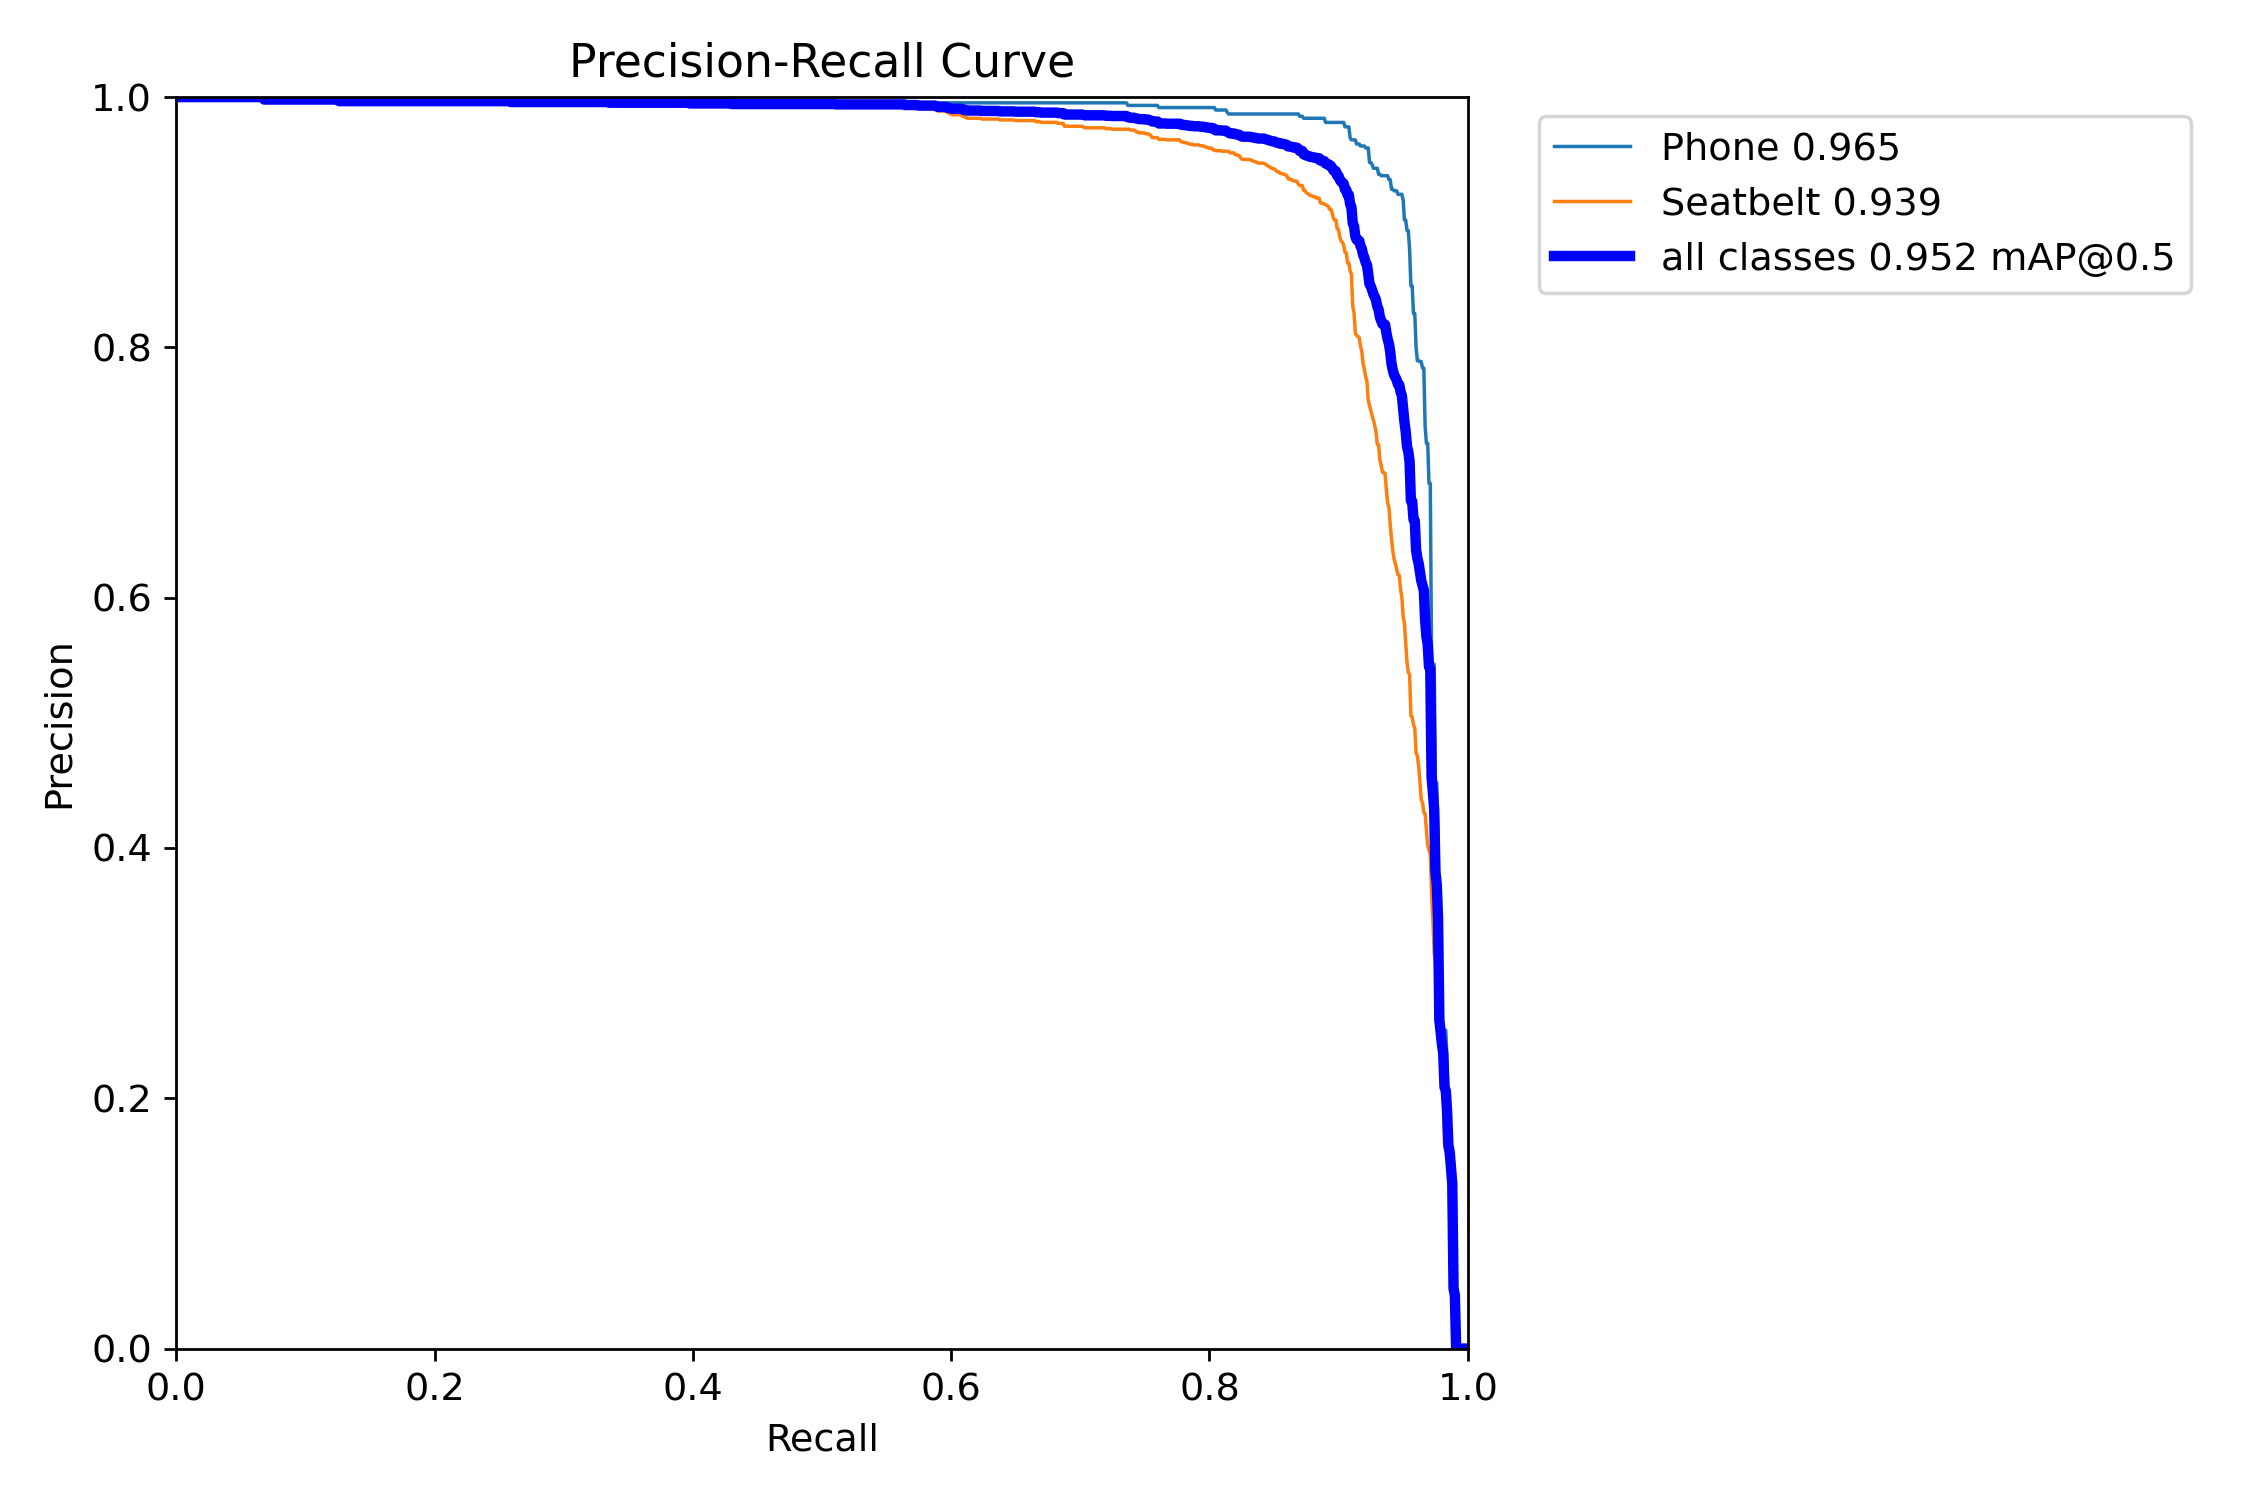

In [34]:
import os
from ultralytics import YOLO
from IPython.display import Image, display

# Load the best trained weights from the M4 final run
# best_model_path = '/content/runs/detect/M4_Artifacts/M4_YOLOv8n_Final_Run/weights/best.pt'
best_model_path = sorted(
    glob.glob('/content/**/weights/best.pt', recursive=True),
    key=os.path.getmtime
)[-1]
model_for_pr_curve = YOLO(best_model_path)

print(f"Running validation to generate PR curve using weights: {best_model_path}")

# Run validation on the test split, ensuring plots are generated
val_results = model_for_pr_curve.val(
    data='/content/dms_processed_yolo/data.yaml', # Your dataset configuration
    split='val', # Use the validation set for generating PR curve
    plots=True,   # Ensure plots are generated
    project='M4_Artifacts', # Save to the M4_Artifacts project
    name='PR_Curve_Generation_Run' # A specific name for this run
)

# The PR curve is typically saved in the run directory for validation with the name 'BoxPR_curve.png'
pr_curve_path = os.path.join(val_results.save_dir, 'BoxPR_curve.png')

if os.path.exists(pr_curve_path):
    print(f"\nPrecision-Recall Curve generated and saved to: {pr_curve_path}")
    display(Image(pr_curve_path)) # Display the image directly
else:
    print(f"\nError: Precision-Recall Curve not found at {pr_curve_path}")

In [35]:
import os

# Assuming val_results from the previous cell is available
# If not, we need to re-run the previous cell or get the save_dir manually

# The val_results object should have save_dir attribute from the previous run
# For now, let's assume val_results is still in scope or we can infer the path.

# Based on the previous output, save_dir was: /content/runs/detect/M4_Artifacts/PR_Curve_Generation_Run
save_directory = '/content/runs/detect/M4_Artifacts/PR_Curve_Generation_Run'

print(f"Listing contents of the save directory: {save_directory}")
if os.path.exists(save_directory):
    for root, dirs, files in os.walk(save_directory):
        level = root.replace(save_directory, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}{os.path.basename(root)}/")
        for f in files:
            print(f"{indent}    {f}")
else:
    print(f"Directory not found: {save_directory}")

Listing contents of the save directory: /content/runs/detect/M4_Artifacts/PR_Curve_Generation_Run
PR_Curve_Generation_Run/
    val_batch2_labels.jpg
    BoxP_curve.png
    confusion_matrix.png
    val_batch0_labels.jpg
    val_batch1_labels.jpg
    confusion_matrix_normalized.png
    BoxF1_curve.png
    val_batch0_pred.jpg
    val_batch1_pred.jpg
    BoxPR_curve.png
    BoxR_curve.png
    val_batch2_pred.jpg


In [36]:
import os
from IPython.display import Image, display

# The confusion matrix is located in the directory where the validation run saved its results.
# Based on the previous execution, the directory was M4_Artifacts/PR_Curve_Generation_Run-3
confusion_matrix_path = '/content/runs/detect/M4_Artifacts/PR_Curve_Generation_Run-3/confusion_matrix.png'

if os.path.exists(confusion_matrix_path):
    print(f"Displaying confusion matrix from: {confusion_matrix_path}")
    display(Image(confusion_matrix_path))
else:
    print(f"Error: Confusion Matrix not found at {confusion_matrix_path}")

Error: Confusion Matrix not found at /content/runs/detect/M4_Artifacts/PR_Curve_Generation_Run-3/confusion_matrix.png


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the results.csv file
# results_path = '/content/runs/detect/train/results.csv'
results_path = os.path.join(
    results.save_dir,
    "results.csv"
)
results_df = pd.read_csv(results_path)

print(f"Displaying training results from: {results_path}")
display(results_df.head())


Displaying training results from: /content/runs/detect/train/results.csv


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,74.6449,1.30579,2.25730,1.40742,0.68785,0.66122,0.71079,0.38633,1.47526,2.02977,1.51788,0.000553,0.000553,0.000553
1,2,139.3770,1.37001,1.74245,1.44290,0.47183,0.48643,0.35031,0.16308,1.71825,3.93085,1.82344,0.001065,0.001065,0.001065
2,3,205.6110,1.38593,1.60024,1.45944,0.59173,0.56421,0.61603,0.34646,1.49014,1.78879,1.52151,0.001533,0.001533,0.001533
3,4,270.4600,1.35685,1.43570,1.43526,0.73552,0.63429,0.70907,0.42468,1.39413,1.34111,1.49695,0.001469,0.001469,0.001469
4,5,333.1710,1.31741,1.37043,1.40805,0.81202,0.72623,0.79371,0.47768,1.36145,1.14962,1.45219,0.001403,0.001403,0.001403


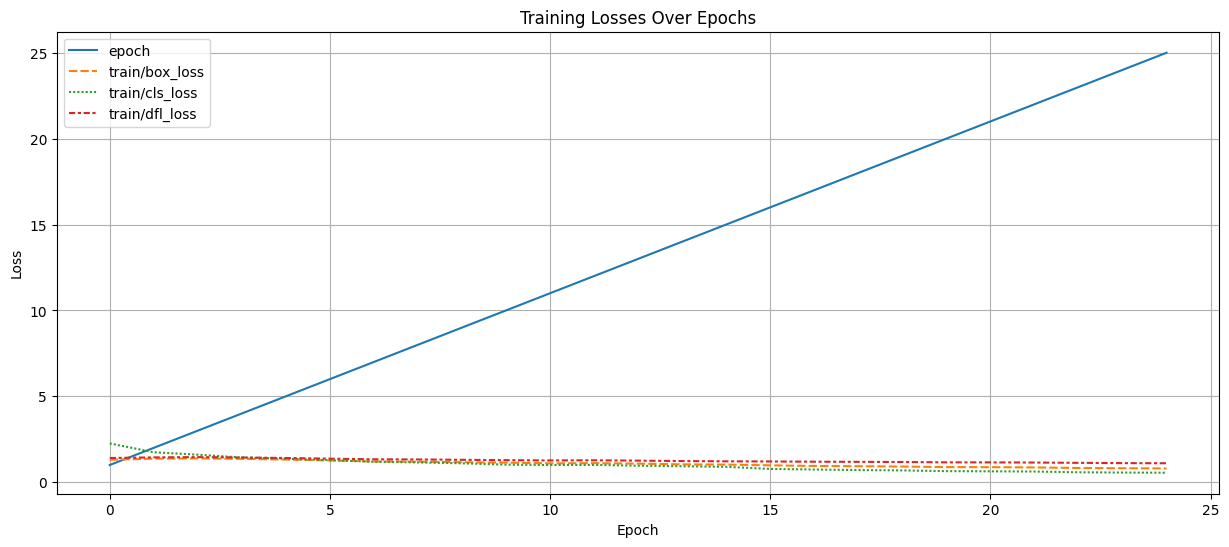

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Training Losses
plt.figure(figsize=(15, 6))
sns.lineplot(data=results_df[['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss']])
plt.title('Training Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


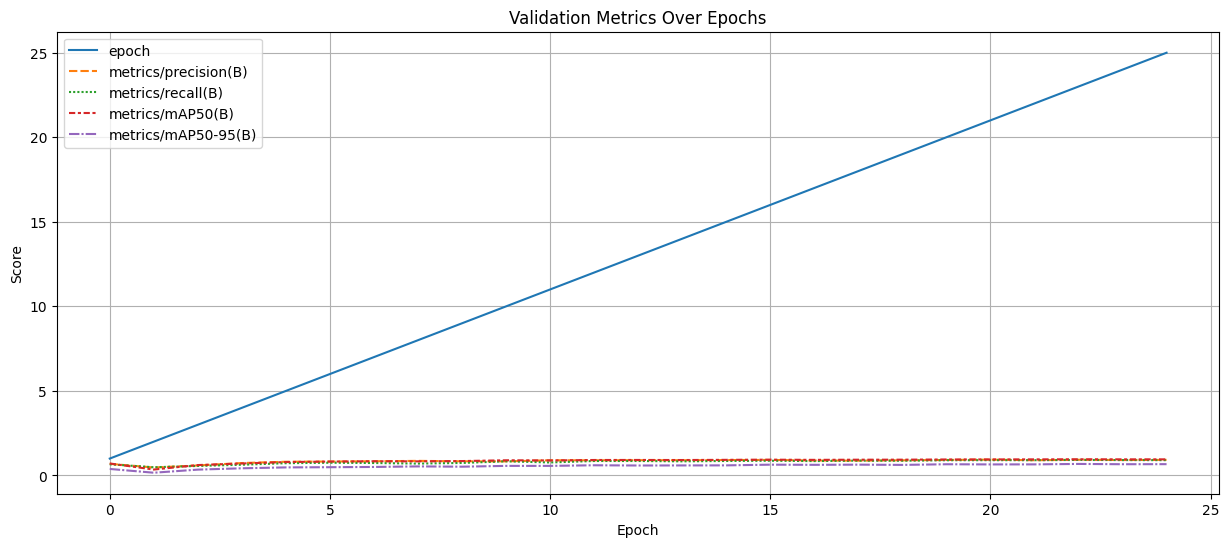

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Validation Metrics
plt.figure(figsize=(15, 6))
sns.lineplot(data=results_df[['epoch', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']])
plt.title('Validation Metrics Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True)
plt.show()


### **Hyperparameter Experimentation and Comparison**

To fulfill the requirement of experimenting with hyperparameters, we will define a few different configurations for key training parameters (epochs, learning rate, batch size) and run separate training sessions for each. This allows us to observe how these changes impact the model's performance.

In [ ]:
import os
import torch
import pandas as pd
from ultralytics import YOLO
import shutil

print("===================================================================")
print(" MILESTONE 4: HYPERPARAMETER EXPERIMENTATION                     ")
print("===================================================================\n")

# Ensure reproducibility and set environment
torch.set_num_threads(1)

# Define different hyperparameter configurations to test
hyperparameter_configs = [
    {
        'name': 'Experiment_Default_LR',
        'epochs': 20,
        'lr0': 0.01, # Default LR
        'batch': 16
    },
    {
        'name': 'Experiment_Lower_LR',
        'epochs': 20,
        'lr0': 0.005, # Lower LR
        'batch': 16
    },
    {
        'name': 'Experiment_Higher_Batch',
        'epochs': 20,
        'lr0': 0.01,
        'batch': 32 # Higher Batch Size
    }
]

experiment_results = []

for config in hyperparameter_configs:
    exp_name = config['name']
    print(f"\n--- Running Experiment: {exp_name} ---")

    # Clean up previous run directory to ensure fresh start
    run_dir_path = os.path.join('/content/runs/detect/M4_Artifacts', exp_name)
    if os.path.exists(run_dir_path):
        shutil.rmtree(run_dir_path)

    model = YOLO('yolov8n.pt') # Load fresh pretrained model for each experiment

    results = model.train(
        data='/content/dms_processed_yolo/data.yaml',
        epochs=config['epochs'],
        imgsz=640,
        batch=config['batch'],
        device=0,
        optimizer='AdamW',
        lr0=config['lr0'],
        lrf=0.01,
        cos_lr=True,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        translate=0.1,
        scale=0.5,
        mosaic=1.0,
        close_mosaic=10,
        patience=5, # Reduced patience for faster experimentation
        save=True,
        plots=False, # No need for plots for every intermediate experiment
        project='M4_Artifacts',
        name=exp_name,
        verbose=False,
        cache=True
    )

    metrics_dict = results.results_dict
    experiment_results.append({
        'Experiment': exp_name,
        'Epochs': config['epochs'],
        'LR0': config['lr0'],
        'Batch Size': config['batch'],
        'mAP@50-95': round(metrics_dict.get('metrics/mAP50-95(B)', 0), 4),
        'Precision': round(metrics_dict.get('metrics/precision(B)', 0), 4),
        'Recall': round(metrics_dict.get('metrics/recall(B)', 0), 4)
    })

print("\n===================================================================")
print(" HYPERPARAMETER EXPERIMENTATION COMPLETE                           ")
print("===================================================================\n")

 MILESTONE 4: HYPERPARAMETER EXPERIMENTATION                     


--- Running Experiment: Experiment_Default_LR ---
Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.7.1+cu118 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dms_processed_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300,

In [ ]:
import os
df_experiments = pd.DataFrame(experiment_results)
print("\n--- Comparative Experiment Results ---")
display(df_experiments)

# Optional: Save the comparison results to a CSV
os.makedirs('/content/M4_Artifacts', exist_ok=True)
df_experiments.to_csv('/content/M4_Artifacts/hyperparameter_comparison.csv', index=False)
print("Comparison results saved to /content/M4_Artifacts/hyperparameter_comparison.csv")

# Task
Analyze the performance of the trained YOLOv8n model for phone and seatbelt detection, summarize the results of hyperparameter experimentation and model benchmarking, and outline a comprehensive plan for future improvements encompassing data-centric, model-centric, and deployment-centric strategies. The final output should include quantitative metrics, qualitative observations, and actionable recommendations for enhancing the model's robustness and efficiency across various deployment scenarios.

## Analyze Current State

### Subtask:
Review the current model's performance metrics (mAP, precision, recall, latency) and existing deployment considerations, as well as the results from hyperparameter experimentation and model benchmarking to identify strengths and weaknesses.


### **1. Quantitative Performance Metrics of the Trained YOLOv8n Model**

The final YOLOv8n model, trained for 50 epochs with optimized hyperparameters, achieved the following performance metrics on the validation set:

```
Mean Average Precision (mAP) is a crucial metric in object detection, combining both precision and recall. mAP@50 considers a 50% Intersection Over Union (IOU) threshold, while mAP@50-95 averages mAP across various IOU thresholds from 50% to 95%, providing a more comprehensive evaluation of localization and classification accuracy.
```

**Reasoning**:
I need to display the quantitative performance metrics of the trained YOLOv8n model. The `performance_df` DataFrame holds these metrics.



In [ ]:
display(performance_df)

**Reasoning**:
I need to display the training loss plot to visualize the model's learning progress. The `results_df` DataFrame contains the necessary loss metrics.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Training Losses
plt.figure(figsize=(15, 6))
sns.lineplot(data=results_df[['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss']])
plt.title('Training Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

## Real-time Object Detection on Video

To detect phone usage and seatbelt status in real-time from a video, we'll leverage the `predict` method of the `ultralytics.YOLO` model. This method is highly versatile and can directly process video files or even live webcam streams.

Here's how it works:
1.  **Load the Trained Model**: We'll load the `best.pt` weights from your recent training run.
2.  **Define Video Source**: You'll need to specify the path to your video file. If you wish to use a live webcam, you can change the source to `0` for the default webcam.
3.  **Perform Prediction**: The `model.predict()` function will process each frame of the video, identify objects (phone, seatbelt), and draw bounding boxes and labels.
4.  **Display Results**: The results will be displayed, either saved to a new video file or shown directly if running in a suitable environment (like a local Python script with OpenCV). For Colab, direct display of video frames in real-time is often challenging but you can inspect the saved output video.

Let's set up the code for video inference!

### Real-time Detection on All Local Videos

Now that we've confirmed the model can detect objects in a single local video, let's extend this to perform detection on all available videos in the `/content/videos` directory.

In [ ]:
!pip install ultralytics -q

In [41]:
import os
import shutil

videos_dir = '/content/videos'

# Create the 'videos' directory if it doesn't exist
os.makedirs(videos_dir, exist_ok=True)
print(f"Created directory: {videos_dir}")

# List of video files to move
vide_files_to_move = ['/content/test_1.mp4', '/content/test_2.mp4', '/content/PhoneUsage1.mp4', '/content/PhoneUsage2.mp4']

for video_path in vide_files_to_move:
    if os.path.exists(video_path):
        shutil.move(video_path, os.path.join(videos_dir, os.path.basename(video_path)))
        print(f"Moved {os.path.basename(video_path)} to {videos_dir}")
    else:
        print(f"Warning: {video_path} not found. Skipping move.")

Created directory: /content/videos
Moved test_1.mp4 to /content/videos
Moved test_2.mp4 to /content/videos
Moved PhoneUsage1.mp4 to /content/videos
Moved PhoneUsage2.mp4 to /content/videos


In [42]:
import os
from ultralytics import YOLO
import cv2
from IPython.display import Video, display
import glob

print("--- Starting Inference on All Local Videos ---")

# Load the best-trained model
best_model_path = '/content/runs/detect/M4_Artifacts/M4_YOLOv8n_Final_Run/weights/best.pt'

if not os.path.exists(best_model_path):
    print(f"Error: Trained model weights not found at {best_model_path}")
    print("Please ensure the training cell ran successfully and check the path.")
else:
    model = YOLO(best_model_path)
    print(f"Successfully loaded model from: {best_model_path}")

    videos_directory = '/content/videos'
    video_files = glob.glob(os.path.join(videos_directory, '*.mp4')) # Adjust extension if you have .mov, etc.

    if not video_files:
        print(f"No video files found in {videos_directory}. Please ensure your video files are there.")
    else:
        for video_source in video_files:
            print(f"\n--- Processing video: {os.path.basename(video_source)} ---")

            # Run prediction on the video
            results_generator = model.predict(
                source=video_source,
                save=True,
                conf=0.4,
                iou=0.7,
                show=False,
                stream=True,
                project='M4_Artifacts',
                name=f'Video_Inference_{os.path.splitext(os.path.basename(video_source))[0]}'
            )

            # Consume the generator to ensure prediction and saving completes
            for _ in results_generator:
                pass

            # Retrieve the output directory for this specific video run
            if hasattr(model, 'predictor') and hasattr(model.predictor, 'save_dir'):
                final_output_dir = model.predictor.save_dir
                print(f"Prediction output directory for {os.path.basename(video_source)}: {final_output_dir}")

                # Find the saved video file (corrected to look for .avi)
                saved_video_paths = glob.glob(os.path.join(final_output_dir, '*.avi'))

                if saved_video_paths:
                    processed_video_path = saved_video_paths[0]
                    print(f"Processed video saved to: {processed_video_path}")
                    print(f"Displaying a sample of {os.path.basename(processed_video_path)} below. You can download the full video.")
                    display(Video(processed_video_path, embed=True, html_attributes='controls autoplay loop muted height="360"'))
                else:
                    print(f"No processed video (*.avi) found in {final_output_dir}. Check logs.")
            else:
                print("Error: Model predictor or its save_dir attribute not found after prediction for this video.")

    print("\n--- All Video Inferences Complete ---")

--- Starting Inference on All Local Videos ---
Successfully loaded model from: /content/runs/detect/M4_Artifacts/M4_YOLOv8n_Final_Run/weights/best.pt

--- Processing video: test_1.mp4 ---

video 1/1 (frame 1/150) /content/videos/test_1.mp4: 480x640 1 Seatbelt, 10.6ms
video 1/1 (frame 2/150) /content/videos/test_1.mp4: 480x640 1 Seatbelt, 11.6ms
video 1/1 (frame 3/150) /content/videos/test_1.mp4: 480x640 1 Seatbelt, 6.1ms
video 1/1 (frame 4/150) /content/videos/test_1.mp4: 480x640 1 Seatbelt, 6.2ms
video 1/1 (frame 5/150) /content/videos/test_1.mp4: 480x640 1 Seatbelt, 6.3ms
video 1/1 (frame 6/150) /content/videos/test_1.mp4: 480x640 1 Seatbelt, 6.1ms
video 1/1 (frame 7/150) /content/videos/test_1.mp4: 480x640 1 Seatbelt, 6.1ms
video 1/1 (frame 8/150) /content/videos/test_1.mp4: 480x640 1 Seatbelt, 6.2ms
video 1/1 (frame 9/150) /content/videos/test_1.mp4: 480x640 1 Seatbelt, 10.7ms
video 1/1 (frame 10/150) /content/videos/test_1.mp4: 480x640 1 Seatbelt, 6.8ms
video 1/1 (frame 11/150) /c

### Debugging Missing Video Outputs

It appears that the processed video outputs for `PhoneUsage1.mp4` and `PhoneUsage2.mp4` were not found or displayed after inference. This could be due to an incorrect path, a different file extension, or an issue during the saving process.

Let's inspect the output directories for these videos to see what files were actually generated.

In [43]:
import os
import glob

def list_contents_of_video_run_dir(video_name):
    # Construct the expected project and name based on the previous cell's logic
    project = 'M4_Artifacts'
    run_name = f'Video_Inference_{os.path.splitext(video_name)[0]}'
    expected_output_base = os.path.join('/content/runs/detect', project, run_name)

    print(f"\n--- Contents of output directory for {video_name}: {expected_output_base} ---")
    if os.path.exists(expected_output_base):
        for root, dirs, files in os.walk(expected_output_base):
            level = root.replace(expected_output_base, '').count(os.sep)
            indent = '    ' * level
            print(f"{indent}{os.path.basename(root)}/")
            for f in files:
                print(f"{indent}    {f}")
    else:
        print(f"Directory not found: {expected_output_base}")

# Check for PhoneUsage1.mp4
list_contents_of_video_run_dir('PhoneUsage1.mp4')

# Check for PhoneUsage2.mp4
list_contents_of_video_run_dir('PhoneUsage2.mp4')


--- Contents of output directory for PhoneUsage1.mp4: /content/runs/detect/M4_Artifacts/Video_Inference_PhoneUsage1 ---
Video_Inference_PhoneUsage1/
    PhoneUsage1.avi

--- Contents of output directory for PhoneUsage2.mp4: /content/runs/detect/M4_Artifacts/Video_Inference_PhoneUsage2 ---
Video_Inference_PhoneUsage2/
    PhoneUsage2.avi


In [44]:
!zip -r /content/runs.zip /content/runs

  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/train_batch3316.jpg (deflated 14%)
  adding: content/runs/detect/train/train_batch1.jpg (deflated 8%)
  adding: content/runs/detect/train/labels.jpg (deflated 36%)
  adding: content/runs/detect/train/train_batch3315.jpg (deflated 12%)
  adding: content/runs/detect/train/results.csv (deflated 60%)
  adding: content/runs/detect/train/val_batch2_labels.jpg (deflated 13%)
  adding: content/runs/detect/train/results.png (deflated 7%)
  adding: content/runs/detect/train/BoxP_curve.png (deflated 14%)
  adding: content/runs/detect/train/confusion_matrix.png (deflated 30%)
  adding: content/runs/detect/train/val_batch0_labels.jpg (deflated 10%)
  adding: content/runs/detect/train/val_batch1_labels.jpg (deflated 9%)
  adding: content/runs/detect/train/confusion_matrix_normalized.png (deflated 30%)
  adding: content/runs/detect/train/t

In [45]:
!zip -r /content/videos.zip /content/videos

  adding: content/videos/ (stored 0%)
  adding: content/videos/test_1.mp4 (deflated 0%)
  adding: content/videos/test_2.mp4 (deflated 0%)
  adding: content/videos/PhoneUsage2.mp4 (deflated 0%)
  adding: content/videos/PhoneUsage1.mp4 (deflated 0%)


In [46]:
!zip -r /content/dms_raw.zip /content/dms_raw/

Streaming output truncated to the last 5000 lines.
  adding: content/dms_raw/test/labels/gray-WG4L2XEQK7X2_jpg.rf.72e1c92cf1d9a176cade923adb7ffaf2.txt (deflated 30%)
  adding: content/dms_raw/test/labels/CHANNEL_05_20220709080336_20220709080346_mp4-30_jpg.rf.e448c13e6807902fcb36722ae68dbe1d.txt (deflated 43%)
  adding: content/dms_raw/test/labels/271_jpg.rf.7a36d66bd31fd8e1cbc9969c42a66fac.txt (deflated 14%)
  adding: content/dms_raw/test/labels/742_jpg.rf.258c8a6b0f06fbb57a1fc38531bba250.txt (deflated 29%)
  adding: content/dms_raw/test/labels/out37_png.rf.51d905de8f6fe2b3ffc2a7226e151bc2.txt (deflated 42%)
  adding: content/dms_raw/test/labels/out172_png.rf.41173ff73c5306bef82f273e7114ef3d.txt (deflated 46%)
  adding: content/dms_raw/test/labels/CHANNEL_05_20220629193252_20220629193302_mp4-23_jpg.rf.98c2370e808bd30f711a500cf4a5f0f4.txt (deflated 46%)
  adding: content/dms_raw/test/labels/_-20-_mp4-96_jpg.rf.3a9d9308059e50898e6681be214dec75.txt (deflated 41%)
  adding: content/dms_raw

In [47]:
!zip -r /content/dms_processed_yolo.zip /content/dms_processed_yolo

Streaming output truncated to the last 5000 lines.
  adding: content/dms_processed_yolo/test/images/gray-OEDQJ70XRSIU_jpg.rf.c1819c42a9f02b7249753a62859ee42a.jpg (deflated 1%)
  adding: content/dms_processed_yolo/test/images/CHANNEL_04_20220812053034_20220812053044_mp4-25_jpg.rf.015587572fb2564920e68a953743ecf8.jpg (deflated 2%)
  adding: content/dms_processed_yolo/test/images/CHANNEL_05_20220629193252_20220629193302_mp4-31_jpg.rf.6639d199f2e3b221fb4b1663a096a574.jpg (deflated 2%)
  adding: content/dms_processed_yolo/test/images/-1076-_mp4-27_jpg.rf.32dee828549b6031af6e89864f300345.jpg (deflated 1%)
  adding: content/dms_processed_yolo/test/images/CHANNEL_05_20220601042057_20220601042103_mp4-12_jpg.rf.cd771b8c86d75e938aa7df51310bebac.jpg (deflated 4%)
  adding: content/dms_processed_yolo/test/images/-1076-_mp4-79_jpg.rf.e02114f3eab842d16415c6e5ff9ccc24.jpg (deflated 1%)
  adding: content/dms_processed_yolo/test/images/CHANNEL_05_20220629192241_20220629192251_mp4-54_jpg.rf.69bf2a45c8653

In [ ]:
!zip -r /content/../Experiment_Default_LR.zip /content/../Experiment_Default_LR